In [1]:
pip install sentence-transformers matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
sentences = [
    # Cricket (4 sentences)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket match by five wickets",
    "The cricket match was exciting till the last over",

    # Cooking (3 sentences)
    "I cooked pasta with tomato sauce",
    "The chef prepared a delicious meal",
    "Baking a cake requires precise measurements",

    # Cybersecurity (3 sentences)
    "Cyber attacks can compromise sensitive data",
    "Strong passwords help protect user accounts",
    "Encryption ensures secure communication"
]

# Check count
print("Total sentences:", len(sentences))

Total sentences: 10


In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings shape: (10, 384)


In [5]:
# Compute similarity matrix (10 x 10)
similarity_matrix = cosine_similarity(embeddings)

# Print matrix
print("Cosine Similarity Matrix:\n")
print(similarity_matrix)

Cosine Similarity Matrix:

[[ 9.99999940e-01  3.83872211e-01  5.97553730e-01  5.25905907e-01
   1.38297146e-02  1.30947992e-01  1.57378361e-01  1.04992643e-01
  -2.69861147e-02  8.26873444e-03]
 [ 3.83872211e-01  1.00000000e+00  3.65226358e-01  3.11293989e-01
   1.34440124e-01  2.21493781e-01  1.06246367e-01  1.05763882e-01
   5.13232276e-02  5.73812984e-02]
 [ 5.97553730e-01  3.65226358e-01  1.00000000e+00  5.73365688e-01
   6.94245994e-02  1.71069294e-01  6.47860393e-02  1.28161073e-01
  -2.00140364e-02  7.65220001e-02]
 [ 5.25905907e-01  3.11293989e-01  5.73365688e-01  9.99999940e-01
  -1.67503394e-03  3.35195176e-02 -4.79815193e-02  1.07302174e-01
  -4.96029332e-02  8.53002369e-02]
 [ 1.38297146e-02  1.34440124e-01  6.94245994e-02 -1.67503394e-03
   1.00000000e+00  3.65874469e-01  1.12457117e-02  6.36361092e-02
   9.82657075e-05  3.99950966e-02]
 [ 1.30947992e-01  2.21493781e-01  1.71069294e-01  3.35195176e-02
   3.65874469e-01  1.00000012e+00  2.54537195e-01  2.23966036e-02
  -1.9

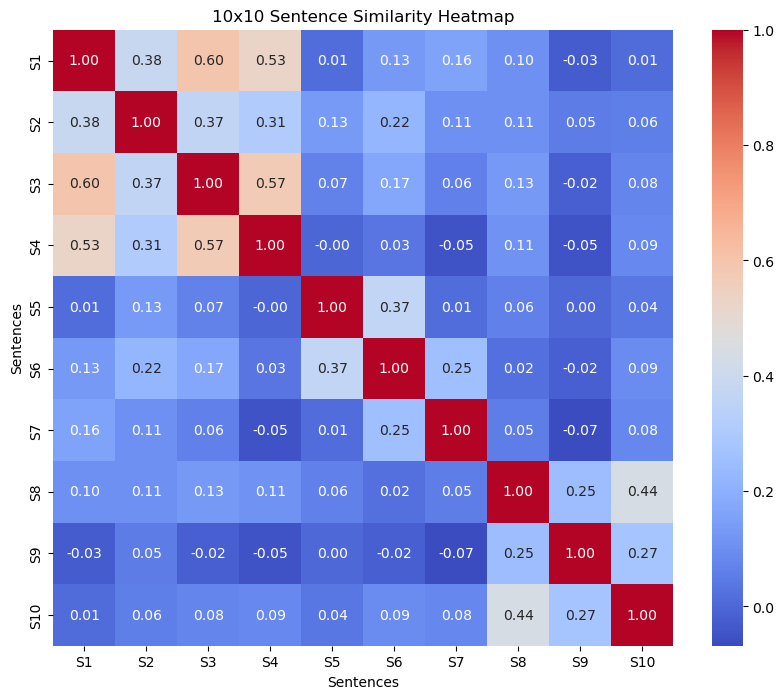

In [6]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=[f"S{i+1}" for i in range(len(sentences))],
    yticklabels=[f"S{i+1}" for i in range(len(sentences))]
)

plt.title("10x10 Sentence Similarity Heatmap")
plt.xlabel("Sentences")
plt.ylabel("Sentences")

plt.show()

In [7]:
query = "The bowler took three wickets in one over"

# Generate embedding for query
query_embedding = model.encode([query])

# Compute similarity with all sentences
similarities = cosine_similarity(query_embedding, embeddings)[0]

print("Query:", query)
print("\nSimilarity Scores:\n")

for i, score in enumerate(similarities):
    print(f"Sentence {i+1}: {sentences[i]}")
    print(f"Score: {score:.4f}")
    print()

Query: The bowler took three wickets in one over

Similarity Scores:

Sentence 1: The batsman scored a century in the match
Score: 0.5682

Sentence 2: The bowler delivered a fast yorker
Score: 0.5414

Sentence 3: The team won the cricket match by five wickets
Score: 0.7251

Sentence 4: The cricket match was exciting till the last over
Score: 0.5158

Sentence 5: I cooked pasta with tomato sauce
Score: 0.1333

Sentence 6: The chef prepared a delicious meal
Score: 0.2078

Sentence 7: Baking a cake requires precise measurements
Score: 0.0857

Sentence 8: Cyber attacks can compromise sensitive data
Score: 0.1163

Sentence 9: Strong passwords help protect user accounts
Score: 0.0360

Sentence 10: Encryption ensures secure communication
Score: -0.0011



In [8]:
# Get indices of top 2 similar sentences
top_indices = np.argsort(similarities)[-2:][::-1]

print("Top 2 Most Similar Sentences:\n")

for i in top_indices:
    print(f"Sentence: {sentences[i]}")
    print(f"Similarity Score: {similarities[i]:.4f}")
    print()

Top 2 Most Similar Sentences:

Sentence: The team won the cricket match by five wickets
Similarity Score: 0.7251

Sentence: The batsman scored a century in the match
Similarity Score: 0.5682

